In [1]:
# MÔI TRƯỜNG & THƯ VIỆN
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Cấu hình hiển thị biểu đồ
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.family'] = 'sans-serif'

# Đọc dữ liệu Golden Record
data_path = Path("../data/final/board_golden.parquet")
try:
    df = pd.read_parquet(data_path)
    print(f"✅ Load thành công {len(df)} bản ghi từ: {data_path}")
except FileNotFoundError:
    print("❌ Không tìm thấy file. Hãy kiểm tra lại đường dẫn!")
    
# Hiển thị 5 dòng đầu
display(df.head())

✅ Load thành công 662 bản ghi từ: ..\data\final\board_golden.parquet


,ticker,exchange,person_name,person_name_canonical,role,age,education,shares,tenure,source_agreement,confidence_score
0,A32,UPCOM,Bà Đặng Thị Thúy Hà,dang thi thuy ha,Thành viên BKS,48.0,CN Kinh tế,5300.0,2000,both,1.0
1,A32,UPCOM,Ông Dương Hoài Nam,duong hoai nam,Thành viên BKS,55.0,C.Đẳng Kinh tế,1200.0,1994,both,1.0
2,A32,UPCOM,Ông Hà Ngọc Oanh,ha ngoc oanh,Trưởng BKS,55.0,CN Kinh tế,8500.0,1993,both,1.0
3,A32,UPCOM,Ông Hoàng Mạnh Cường,hoang manh cuong,KTT,NaN,Cử nhân,0.0,None,vietstock_only,0.8
4,A32,UPCOM,Ông Ngô Thành Thắng,ngo thanh thang,Phó Chủ tịch HĐQT / Tổng Giám đốc,49.0,Cử nhân,886100.0,1996,conflict,0.6


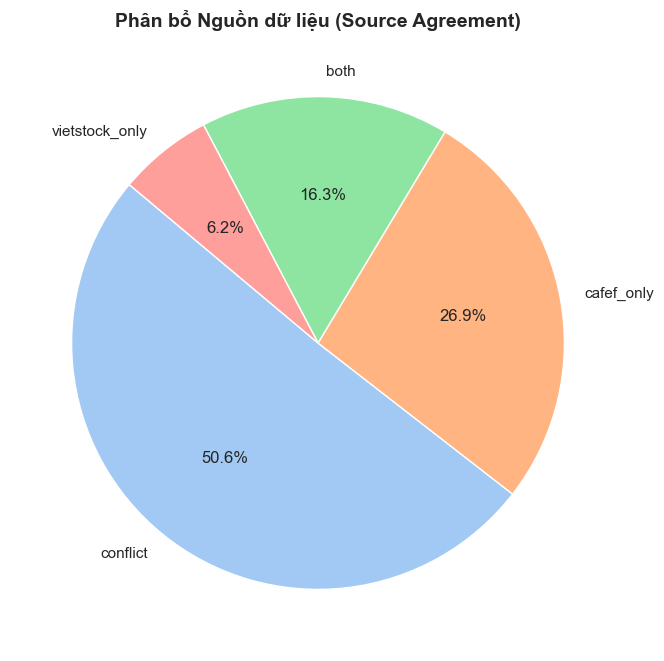


Thống kê Điểm tin cậy (Confidence Score):


,count
confidence_score,
0.6,335
0.8,219
1.0,108


In [2]:
# THỐNG KÊ MỨC ĐỘ ĐỒNG THUẬN GIỮA CÁC NGUỒN (Source Agreement)
agreement_counts = df['source_agreement'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(agreement_counts, labels=agreement_counts.index, autopct='%1.1f%%', 
        startangle=140, colors=sns.color_palette("pastel"))
plt.title("Phân bổ Nguồn dữ liệu (Source Agreement)", fontsize=14, fontweight='bold')
plt.show()

# ĐIỂM TIN CẬY (Confidence Score)
print("\nThống kê Điểm tin cậy (Confidence Score):")
display(df['confidence_score'].value_counts(dropna=False).to_frame())

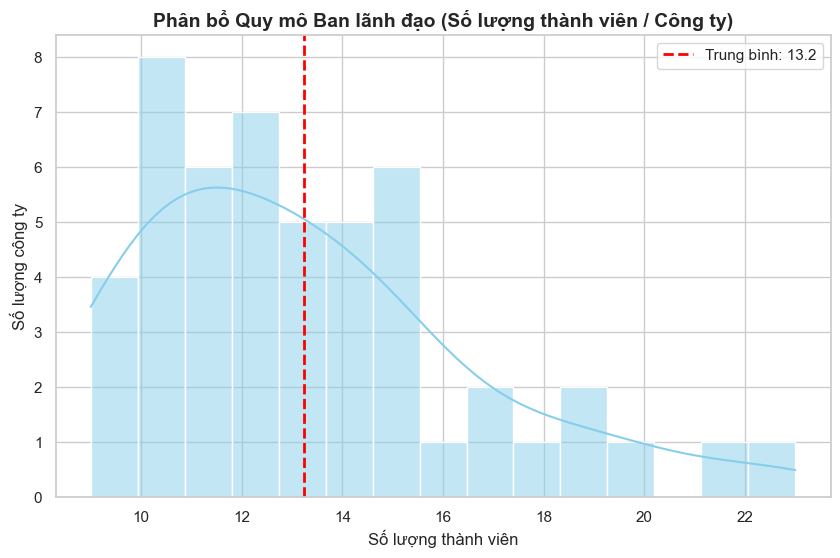

In [3]:
# TÍNH TOÁN SỐ LƯỢNG THÀNH VIÊN BAN LÃNH ĐẠO TRUNG BÌNH MỖI CÔNG TY
board_size = df.groupby('ticker')['person_name'].count().reset_index()
board_size.rename(columns={'person_name': 'board_members_count'}, inplace=True)

plt.figure(figsize=(10, 6))
sns.histplot(board_size['board_members_count'], bins=15, kde=True, color='skyblue')
plt.title("Phân bổ Quy mô Ban lãnh đạo (Số lượng thành viên / Công ty)", fontsize=14, fontweight='bold')
plt.xlabel("Số lượng thành viên")
plt.ylabel("Số lượng công ty")
plt.axvline(board_size['board_members_count'].mean(), color='red', linestyle='dashed', linewidth=2, label=f'Trung bình: {board_size["board_members_count"].mean():.1f}')
plt.legend()
plt.show()

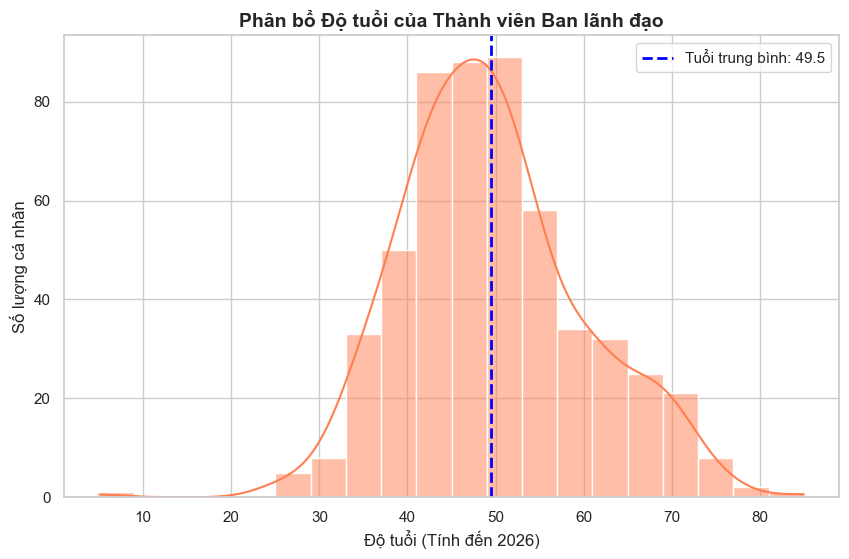

C:\Users\admin\AppData\Local\Temp\ipykernel_12608\1257596866.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_age, x='exchange', y='age', palette='Set2')


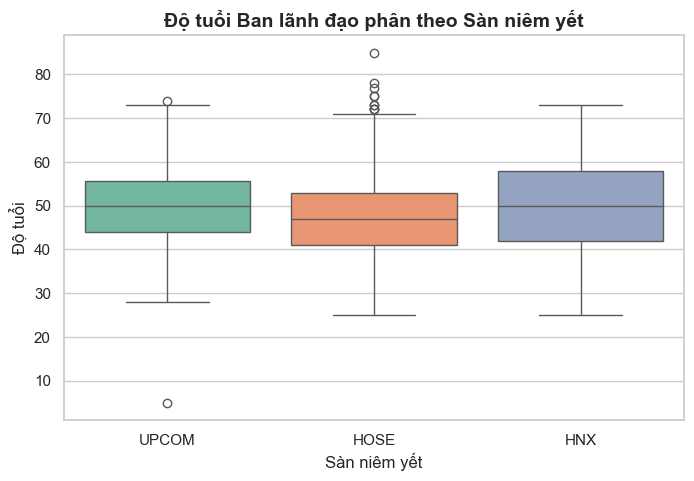

In [4]:
# LỌC CÁC BẢN GHI CÓ ĐỘ TUỔI HỢP LỆ (Lớn hơn 0)
df_age = df[df['age'] > 0].copy()

plt.figure(figsize=(10, 6))
sns.histplot(df_age['age'], bins=20, kde=True, color='coral')
plt.title("Phân bổ Độ tuổi của Thành viên Ban lãnh đạo", fontsize=14, fontweight='bold')
plt.xlabel("Độ tuổi (Tính đến 2026)")
plt.ylabel("Số lượng cá nhân")
plt.axvline(df_age['age'].mean(), color='blue', linestyle='dashed', linewidth=2, label=f'Tuổi trung bình: {df_age["age"].mean():.1f}')
plt.legend()
plt.show()

# Tuổi trung bình theo Sàn giao dịch
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_age, x='exchange', y='age', palette='Set2')
plt.title("Độ tuổi Ban lãnh đạo phân theo Sàn niêm yết", fontsize=14, fontweight='bold')
plt.xlabel("Sàn niêm yết")
plt.ylabel("Độ tuổi")
plt.show()

C:\Users\admin\AppData\Local\Temp\ipykernel_12608\2518388892.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_roles.index, x=top_roles.values, palette='viridis')


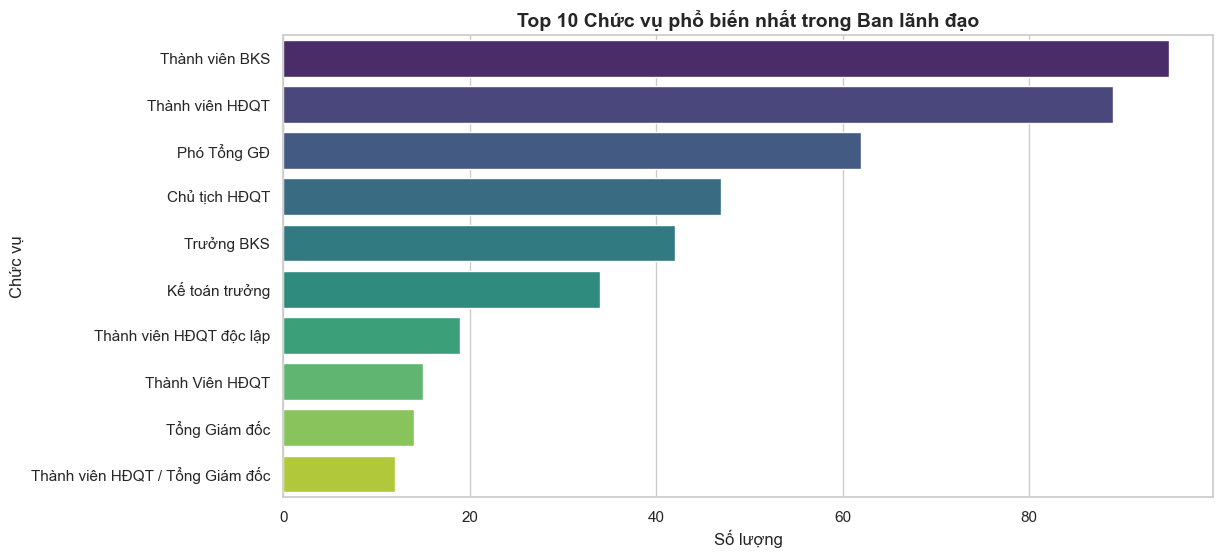

In [5]:
# LẤY TOP 10 CHỨC VỤ PHỔ BIẾN NHẤT
# Lưu ý: Các chức vụ đã được gộp (kiêm nhiệm) sẽ có dấu "/"
top_roles = df['role'].value_counts().head(10)

plt.figure(figsize=(12, 6))
sns.barplot(y=top_roles.index, x=top_roles.values, palette='viridis')
plt.title("Top 10 Chức vụ phổ biến nhất trong Ban lãnh đạo", fontsize=14, fontweight='bold')
plt.xlabel("Số lượng")
plt.ylabel("Chức vụ")
plt.show()

In [6]:
# Đếm số lượng dấu "/" trong cột role để xác định số chức vụ kiêm nhiệm
df['role_count'] = df['role'].astype(str).apply(lambda x: x.count('/') + 1 if pd.notna(x) and x != 'None' else 1)

multi_role_df = df[df['role_count'] >= 2].sort_values(by='role_count', ascending=False)
print(f"Tổng số nhân sự kiêm nhiệm từ 2 chức vụ trở lên: {len(multi_role_df)}")

# Hiển thị top 5 người kiêm nhiệm nhiều nhất
display(multi_role_df[['ticker', 'person_name', 'role', 'role_count']].head())

Tổng số nhân sự kiêm nhiệm từ 2 chức vụ trở lên: 109


,ticker,person_name,role,role_count
476,AMV,Bà Đặng Nhị Nương,Thành viên HĐQT / Phụ trách quản trị / Giám đố...,4
545,API,Bà Nguyễn Phương Dung,Thành viên HĐQT / Phụ trách quản trị / Tổng Gi...,4
618,BBS,Ông Dương Minh Tuấn,Phó Giám đốc / Kế toán trưởng / Người được ủy ...,3
243,ACE,Ông Trịnh Tấn Đệ,Phụ trách quản trị / Kế toán trưởng / Thư ký c...,3
515,ANV,Ông Trần Minh Cảnh,Thành viên HĐQT / Phó Tổng GĐ / Công bố thông tin,3
